# Project Milestone Two

**Data Preparation and Model Exploration**

**Note: No late assignments accepted, we need the time to grade them!**

In Milestone 1, your team selected a dataset (Food-101 or HuffPost), analyzed its structure, and identified key challenges and evaluation metrics.
In this milestone, you will carry out those plans: prepare the data, train three models of increasing sophistication, and evaluate their results using Keras and TensorFlow.
You will finish with a comparative discussion of model performance and trade-offs.


### Submission Guidelines

* Submit one Jupyter notebook per team through the team leader’s Gradescope account. **Include all team members names at the top of the notebook.**
* Include all code, plots, and answers inline below.
* Ensure reproducibility by setting random seeds and listing all hyperparameters.
* Document any AI tools used, as required by the CDS policy.


## Problem 1 – Data Preparation and Splits (20 pts)

### Goals

Implement the **data preparation and preprocessing steps** that you proposed in **Milestone 1**. You’ll clean, normalize, and split your data so that it’s ready for modeling and reproducible fine-tuning.

### Steps to Follow

1. **Load your chosen dataset**

   * Use `datasets.load_dataset()` from **Hugging Face** to load **Food-101** or **HuffPost**.
   * Display basic information (e.g., number of samples, feature names, example entries).

2. **Apply cleaning and normalization**

   * **Images:**

     * Ensure all images are in RGB format.
     * Resize or crop to a consistent shape (e.g., `224 × 224`).
     * Drop or fix any corrupted files.
   * **Text:**

     * Concatenate headline + summary (for HuffPost).
     * Strip whitespace, convert to lowercase if appropriate, and remove empty samples.
     * Optionally remove duplicates or extremely short entries.

3. **Standardize or tokenize the inputs**

   * **Images:**

     * Normalize pixel values (e.g., divide by 255.0).
     * Define a minimal augmentation pipeline (e.g., random flip, crop, or rotation).
   * **Text:**

     * Create a tokenizer or `TextVectorization` layer.
     * Set a target `max_length` based on your analysis from Milestone 1 (e.g., 95th percentile).
     * Apply padding/truncation and build tensors for input + labels.

4. **Handle dataset-specific challenges**

   * If you identified **class imbalance**, compute label counts and, if needed, create a dictionary of `class_weights`.
   * If you noted **length or size variance**, verify that your truncation or resizing works as intended.
   * If you planned **noise filtering**, include the cleaning step and briefly explain your criteria (e.g., remove items with missing text or unreadable images).

5. **Create reproducible splits**

   * Split your cleaned dataset into **train**, **validation**, and **test** subsets (e.g., 80 / 10 / 10).
   * Use a fixed random seed for reproducibility (`random_seed = 42`).
   * Use **stratified splits**  (e.g., with `train_test_split` and `stratify = labels`).
   * Display the size of each subset.

6. **Document your pipeline**

   * Summarize your preprocessing steps clearly in Markdown or code comments.
   * Save or display a few representative examples after preprocessing to confirm the transformations are correct.




In [1]:
# Your code here; add as many cells as you need but make it clear what the structure is.
# ============================================
# Useful Imports
# ============================================

# --- Standard Libraries
import os
import time
import math
import random
from collections import Counter

# --- Core Data / Numerics
import numpy as np
import pandas as pd

# --- Visualization
import matplotlib.pyplot as plt
# import seaborn as sns              # optional
import matplotlib.ticker as mticker  # optional (for formatted axes)

# --- NLP / Tokenization
import spacy                         # used for text preprocessing (HuffPost)

# --- Progress Tracking
from tqdm import tqdm                # optional (nice for loops)

from IPython.display import display

# --- TensorFlow / Keras (Deep Learning)
import tensorflow as tf
from tensorflow.keras import layers, models, Input, callbacks, regularizers, initializers
from tensorflow.keras.callbacks import Callback, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.optimizers.schedules import CosineDecay, ExponentialDecay
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.layers import (
    Dense, Dropout, Flatten, MaxPooling2D, Conv2D,
    SeparableConv2D, GlobalAveragePooling2D, GlobalMaxPooling2D, BatchNormalization
)

# --- (Optional) Classical ML Baseline Tools
# from sklearn.pipeline import Pipeline
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score


# ============================================
# Global Configuration & Small Utilities
# ============================================

# Reproducibility
random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
tf.keras.utils.set_random_seed(random_seed)   # sets Python, NumPy, and TensorFlow seeds

# Utility: format seconds as HH:MM:SS

"""
Example usage to time your code:

start_time = time.time()
# ... your code here ...
print("Execution Time:", format_hms(time.time() - start_time))
"""

def format_hms(seconds: float) -> str:
    """Convert seconds to HH:MM:SS format."""
    return time.strftime("%H:%M:%S", time.gmtime(seconds))


In [2]:

from google.colab import userdata
from huggingface_hub import login

# Retrieve the secret and log in
token = userdata.get('HF_TOKEN')
login(token)

In [3]:
# If needed (in a new env):

!pip install -U datasets pillow

In [3]:
# --- Hugging Face Datasets
from datasets import load_dataset, DatasetDict
from datasets.features import ClassLabel

In [4]:
# JSON mirror that preserves fields: headline, short_description, category, authors, link, date
URL = "https://huggingface.co/datasets/khalidalt/HuffPost/resolve/main/News_Category_Dataset_v2.json"
huff_all = load_dataset("json", data_files=URL, split="train")

print(huff_all)
print("Columns:", huff_all.column_names)
print("Total rows:", len(huff_all))

Dataset({
    features: ['category', 'headline', 'authors', 'link', 'short_description', 'date'],
    num_rows: 200853
})
Columns: ['category', 'headline', 'authors', 'link', 'short_description', 'date']
Total rows: 200853


In [6]:
# M1

ex = huff_all[0]
print("One example:")
print("  category          :", ex.get("category"))
print("  headline          :", (ex.get("headline") or "")[:120])
print("  authors           :", (ex.get("authors") or "")[:120])
print("  short_description :", (ex.get("short_description") or "")[:120])
print("  date              :", ex.get("date"))

One example:
  category          : CRIME
  headline          : There Were 2 Mass Shootings In Texas Last Week, But Only 1 On TV
  authors           : Melissa Jeltsen
  short_description : She left her husband. He killed their children. Just another day in America.
  date              : 2018-05-26 00:00:00


In [7]:
# Show k random lines: "headline [SEP] short_description"

#M1

k = 10
seed = 7
rng = random.Random(seed)
idxs = rng.sample(range(len(huff_all)), k)

for i in idxs:
    ex = huff_all[i]
    print("  category          :", ex.get("category"))
    print("  headline          :", (ex.get("headline") or ""))
    print("  short_description :", (ex.get("short_description") or ""))
    print("  sample text       :", (ex.get("headline") or "")+'  [SEP]  '+ (ex.get("short_description") or ""))
    print()

  category          : ENTERTAINMENT
  headline          : Pregnant Kim Kardashian Rocks A Sheer Jumpsuit At The Airport
  short_description : Forget what you thought you knew about maternity style, because Kim's changing the game.
  sample text       : Pregnant Kim Kardashian Rocks A Sheer Jumpsuit At The Airport  [SEP]  Forget what you thought you knew about maternity style, because Kim's changing the game.

  category          : WOMEN
  headline          : How I Outran Misogyny
  short_description : "I have started running to retrain the way my brain sees my body, not as a sexual object but as a tool to get things done."
  sample text       : How I Outran Misogyny  [SEP]  "I have started running to retrain the way my brain sees my body, not as a sexual object but as a tool to get things done."

  category          : RELIGION
  headline          : A Prayer From the Mall of America
  short_description : I thank you for the Bloomington Police Department, and the Mall of America Security

In [8]:
# ============================================================
# Problem 1: HuffPost EDA
# Build a clean working table for analysis
# ============================================================

#M1

huff_df = pd.DataFrame({
    "category": huff_all["category"],
    "headline": huff_all["headline"],
    "short_description": huff_all["short_description"],
    "authors": huff_all["authors"],
    "date": huff_all["date"]
})

# Fill missing text so string operations do not fail later
huff_df["headline"] = huff_df["headline"].fillna("").astype(str).str.strip()
huff_df["short_description"] = huff_df["short_description"].fillna("").astype(str).str.strip()

# Combine headline and description into one text field
huff_df["text"] = huff_df["headline"] + " [SEP] " + huff_df["short_description"]

print("Shape of working DataFrame:", huff_df.shape)
display(huff_df.head())

Shape of working DataFrame: (200853, 6)


,category,headline,short_description,authors,date,text
0,CRIME,There Were 2 Mass Shootings In Texas Last Week...,She left her husband. He killed their children...,Melissa Jeltsen,2018-05-26,There Were 2 Mass Shootings In Texas Last Week...
1,ENTERTAINMENT,Will Smith Joins Diplo And Nicky Jam For The 2...,Of course it has a song.,Andy McDonald,2018-05-26,Will Smith Joins Diplo And Nicky Jam For The 2...
2,ENTERTAINMENT,Hugh Grant Marries For The First Time At Age 57,The actor and his longtime girlfriend Anna Ebe...,Ron Dicker,2018-05-26,Hugh Grant Marries For The First Time At Age 5...
3,ENTERTAINMENT,Jim Carrey Blasts 'Castrato' Adam Schiff And D...,The actor gives Dems an ass-kicking for not fi...,Ron Dicker,2018-05-26,Jim Carrey Blasts 'Castrato' Adam Schiff And D...
4,ENTERTAINMENT,Julianna Margulies Uses Donald Trump Poop Bags...,"The ""Dietland"" actress said using the bags is ...",Ron Dicker,2018-05-26,Julianna Margulies Uses Donald Trump Poop Bags...


In [9]:
# ============================================================
# Basic dataset summary
# ============================================================

#M1

print(f"Total rows        : {len(huff_df):,}")
print(f"Number of classes : {huff_df['category'].nunique()}")

print("\nRandom sample rows:")
display(huff_df.sample(5, random_state=42)[["category", "headline", "short_description"]])

Total rows        : 200,853
Number of classes : 41

Random sample rows:


,category,headline,short_description
56274,CRIME,Shooting Rampage Results In 'Mass Casualties' ...,"ORLANDO, Fla., June 12 (Reuters) - A gunman ki..."
9929,POLITICS,"Donald Trump Lashes Out At CNN, ABC Over Repor...","The president criticized the ""fake news media""..."
163271,STYLE & BEAUTY,Model Kate Moss Walks Louis Vuitton RTW Fall 2013,Golden girl model Kate Moss wowed in her usual...
190013,DIVORCE,7 Ways Single Moms Cope With Loneliness,“Am I the only single mom feeling lonely out t...
13564,POLITICS,Sen. Sherrod Brown: Steve Bannon 'Is A White S...,"Echoing comments by Rep. Frederica Wilson, he ..."


Top 10 largest categories:


,count
category,
POLITICS,32739
WELLNESS,17827
ENTERTAINMENT,16058
TRAVEL,9887
STYLE & BEAUTY,9649
PARENTING,8677
HEALTHY LIVING,6694
QUEER VOICES,6314
FOOD & DRINK,6226



Top 10 smallest categories:


,count
category,
MONEY,1707
ARTS,1509
FIFTY,1401
GOOD NEWS,1398
ARTS & CULTURE,1339
ENVIRONMENT,1323
COLLEGE,1144
LATINO VOICES,1129
CULTURE & ARTS,1030



Class balance summary
Largest class size : 32,739
Median class size  : 3,405
Smallest class size: 1,004
Imbalance ratio    : 9.61


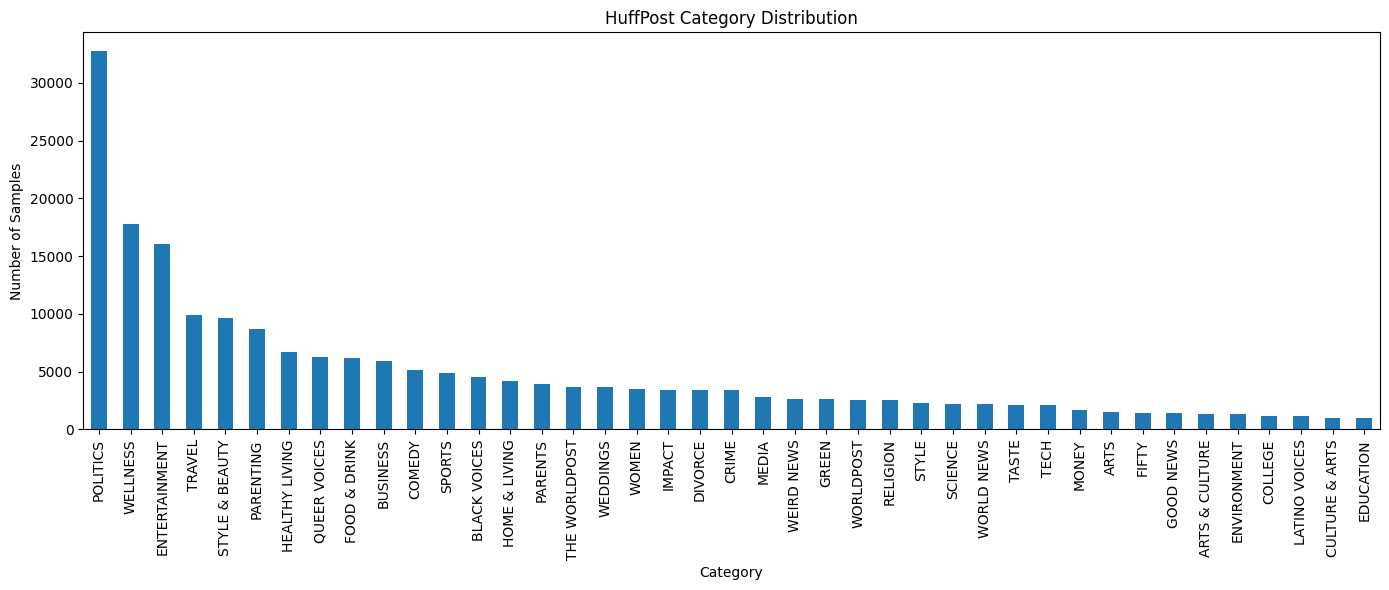

In [10]:
# ============================================================
# Class distribution
# ============================================================

#M1

category_counts = huff_df["category"].value_counts().sort_values(ascending=False)

largest_class = category_counts.max()
smallest_class = category_counts.min()
median_class = category_counts.median()
imbalance_ratio = largest_class / median_class

print("Top 10 largest categories:")
display(category_counts.head(10))

print("\nTop 10 smallest categories:")
display(category_counts.tail(10))

print("\nClass balance summary")
print(f"Largest class size : {largest_class:,}")
print(f"Median class size  : {int(median_class):,}")
print(f"Smallest class size: {smallest_class:,}")
print(f"Imbalance ratio    : {imbalance_ratio:.2f}")

plt.figure(figsize=(14, 6))
category_counts.plot(kind="bar")
plt.title("HuffPost Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Samples")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [11]:
SHORT_THRESHOLD = 5  # check for categories with small
huff_df["word_count"] = huff_df["text"].str.split().str.len()

short_df = huff_df[huff_df["word_count"] <= SHORT_THRESHOLD].copy()

print("Total short samples:", len(short_df))




Total short samples: 981


In [12]:
huff_df["word_count"] = huff_df["text"].str.split().str.len()

short_df = huff_df[huff_df["word_count"] <= SHORT_THRESHOLD].copy()

print("Total short samples:", len(short_df))

Total short samples: 981


In [13]:
short_counts = short_df["category"].value_counts()
print(short_counts)

category
COMEDY            153
HEALTHY LIVING    134
POLITICS          117
ENTERTAINMENT      60
RELIGION           55
WORLDPOST          53
BUSINESS           40
SPORTS             39
TRAVEL             34
ARTS               31
WEIRD NEWS         24
MEDIA              24
IMPACT             23
WOMEN              23
FIFTY              21
TASTE              21
GREEN              19
CRIME              16
STYLE              13
BLACK VOICES       12
EDUCATION          12
GOOD NEWS          11
QUEER VOICES       11
SCIENCE             8
PARENTS             7
COLLEGE             7
FOOD & DRINK        3
TECH                2
LATINO VOICES       2
WELLNESS            2
HOME & LIVING       2
STYLE & BEAUTY      1
CULTURE & ARTS      1
Name: count, dtype: int64


In [14]:
short_mask = huff_df["word_count"] <= SHORT_THRESHOLD

# remove short texts ONLY from politics
filtered_df = huff_df[~((short_mask) & (huff_df["category"] == "POLITICS"))]

In [9]:
# ============================================================
# Missing, weak, and duplicate text
# ============================================================

#M1

huff_df["headline_is_empty"] = huff_df["headline"].str.len() == 0
huff_df["description_is_empty"] = huff_df["short_description"].str.len() == 0
huff_df["both_empty"] = huff_df["headline_is_empty"] & huff_df["description_is_empty"]

# Word count helps identify weak or extremely short examples
huff_df["word_count"] = huff_df["text"].str.split().str.len()

duplicate_count = huff_df["text"].duplicated().sum()

print("Empty text checks")
print(f"Empty headlines          : {huff_df['headline_is_empty'].sum():,}")
print(f"Empty short descriptions : {huff_df['description_is_empty'].sum():,}")
print(f"Both fields empty        : {huff_df['both_empty'].sum():,}")
print(f"Very short rows (<=5)    : {(huff_df['word_count'] <= 5).sum():,}")
print(f"Duplicate combined texts : {duplicate_count:,}")

display(
    huff_df.loc[huff_df["word_count"] <= 5, ["category", "headline", "short_description"]]
    .head(10)
)

Empty text checks
Empty headlines          : 6
Empty short descriptions : 19,712
Both fields empty        : 5
Very short rows (<=5)    : 981
Duplicate combined texts : 488


,category,headline,short_description
12099,COMEDY,The Big Blue Wave,
22303,COMEDY,Trump's America,A limerick.
23764,POLITICS,Cuba Flee-bré,Get it?
25814,COMEDY,The Bechdel Test,
34710,TASTE,Bacardi: A Rum Story,
34712,BUSINESS,Pet Health Insurance,
34714,POLITICS,Health Care Reform,
35276,COMEDY,Constitutional Crossroads,
35278,FIFTY,"Love, Facebook and Infidelity",
37835,IMPACT,Home for Christmas,


Word count summary:
count    200853.000000
mean         30.266852
std          14.046934
min           1.000000
25%          21.000000
50%          29.000000
75%          36.000000
max         246.000000
Name: word_count, dtype: float64

Important word-count percentiles:
50th percentile: 29
75th percentile: 36
90th percentile: 50
95th percentile: 57
99th percentile: 68


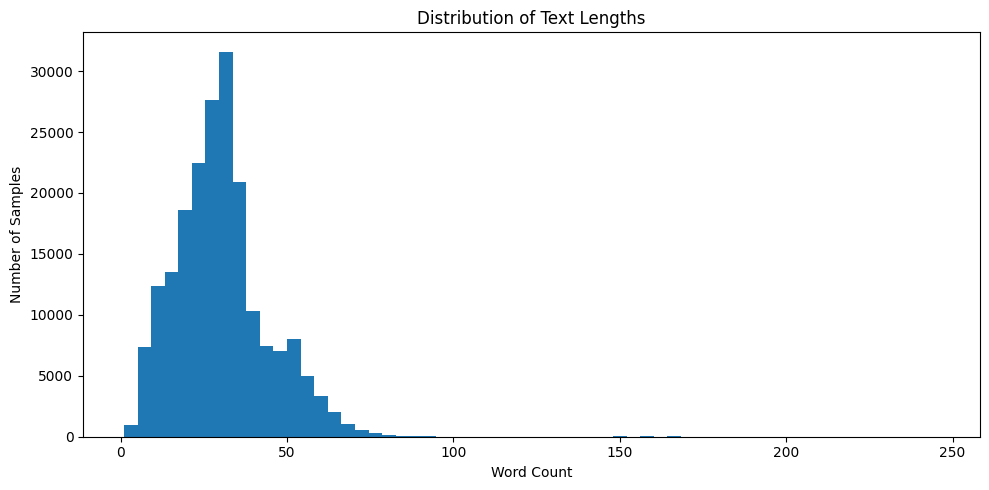

In [13]:
# ============================================================
# Text-length analysis
# ============================================================

#M1

huff_df["char_count"] = huff_df["text"].str.len()

print("Word count summary:")
print(huff_df["word_count"].describe())

print("\nImportant word-count percentiles:")
for p in [50, 75, 90, 95, 99]:
    print(f"{p}th percentile: {np.percentile(huff_df['word_count'], p):.0f}")

plt.figure(figsize=(10, 5))
plt.hist(huff_df["word_count"], bins=60)
plt.title("Distribution of Text Lengths")
plt.xlabel("Word Count")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# Candidate max lengths
# ============================================================

#M1

candidate_lengths = [32, 64, 96, 128]

print("Estimated truncation rates")
for max_len in candidate_lengths:
    trunc_rate = (huff_df["word_count"] > max_len).mean() * 100
    print(f"max_text_length = {max_len:>3}: {trunc_rate:6.2f}% would be truncated")

Estimated truncation rates
max_text_length =  32:  36.68% would be truncated
max_text_length =  64:   1.60% would be truncated
max_text_length =  96:   0.11% would be truncated
max_text_length = 128:   0.08% would be truncated


In [15]:
# ============================================================
# Likely overlapping / ambiguous labels
# ============================================================
# These category pairs may be harder to separate because they
# cover related topics and may use similar language.

#M1

overlap_pairs = [
    ("ARTS", "ARTS & CULTURE"),
    ("ARTS & CULTURE", "CULTURE & ARTS"),
    ("THE WORLDPOST", "WORLDPOST"),
    ("WORLDPOST", "WORLD NEWS"),
    ("POLITICS", "WORLD NEWS"),
    ("PARENTS", "PARENTING"),
    ("WELLNESS", "HEALTHY LIVING"),
    ("STYLE", "STYLE & BEAUTY"),
    ("TASTE", "FOOD & DRINK")
]

print("Likely overlapping category pairs:")
for left_cat, right_cat in overlap_pairs:
    if left_cat in huff_df["category"].unique() and right_cat in huff_df["category"].unique():
        print(f"- {left_cat} vs {right_cat}")

Likely overlapping category pairs:
- ARTS vs ARTS & CULTURE
- ARTS & CULTURE vs CULTURE & ARTS
- THE WORLDPOST vs WORLDPOST
- WORLDPOST vs WORLD NEWS
- POLITICS vs WORLD NEWS
- PARENTS vs PARENTING
- WELLNESS vs HEALTHY LIVING
- STYLE vs STYLE & BEAUTY
- TASTE vs FOOD & DRINK


In [16]:
# ============================================================
# Problem 2: Class imbalance summary
# ============================================================
# This summarizes how uneven the category sizes and helps
# justify later choices such as macro-F1 and class weighting.

#M1

category_counts = huff_df["category"].value_counts().sort_values(ascending=False)

largest_class = category_counts.max()
smallest_class = category_counts.min()
median_class = category_counts.median()
imbalance_ratio = largest_class / median_class

print("Class imbalance summary")
print(f"Largest class size : {largest_class:,}")
print(f"Median class size  : {int(median_class):,}")
print(f"Smallest class size: {smallest_class:,}")
print(f"Imbalance ratio    : {imbalance_ratio:.2f}")

print("\nSmallest categories:")
display(category_counts.sort_values().head(10))

Class imbalance summary
Largest class size : 32,739
Median class size  : 3,405
Smallest class size: 1,004
Imbalance ratio    : 9.61

Smallest categories:


,count
category,
EDUCATION,1004
CULTURE & ARTS,1030
LATINO VOICES,1129
COLLEGE,1144
ENVIRONMENT,1323
ARTS & CULTURE,1339
GOOD NEWS,1398
FIFTY,1401
ARTS,1509


In [17]:
# ------------------------------------------------------------
# Text length patterns
# ------------------------------------------------------------
# This shows how long the combined texts usually are and helps
# guide the later sequence-length decision.

#M1

print("Word-count percentiles")
for p in [50, 75, 90, 95, 99]:
    value = np.percentile(huff_df["word_count"], p)
    print(f"{p}th percentile: {value:.0f}")

# Estimate how many examples would be cut off
# for a few possible sequence lengths.
candidate_lengths = [32, 64, 96, 128]

print("\nEstimated truncation rates")
for max_len in candidate_lengths:
    trunc_rate = (huff_df["word_count"] > max_len).mean() * 100
    print(f"max_text_length = {max_len:>3}: {trunc_rate:6.2f}% would be truncated")

Word-count percentiles
50th percentile: 29
75th percentile: 36
90th percentile: 50
95th percentile: 57
99th percentile: 68

Estimated truncation rates
max_text_length =  32:  36.68% would be truncated
max_text_length =  64:   1.60% would be truncated
max_text_length =  96:   0.11% would be truncated
max_text_length = 128:   0.08% would be truncated


In [18]:
# ============================================================
# Challenge-to-solution plan
# ============================================================
# This connects the EDA findings to practical next steps for

# Milestone 1 -> 2

solution_plan = pd.DataFrame({
    "Challenge": [
        "Class imbalance",
        "Variable text length",
        "Duplicates / leakage risk",
        "Empty or very short text",
        "Overlapping labels",
        "Compute constraints"
    ],
    "Planned approach": [
        "Use stratified train/validation/test splits and try class weights first",
        "Choose a practical max sequence length based on percentile results",
        "Deduplicate before splitting the data",
        "Keep headline-only rows initially but review whether very short rows should be filtered",
        "Inspect confusion patterns later and revisit closely related labels if needed",
        "Start with a moderate sequence length and batch size to keep training practical"
    ]
})

display(solution_plan)

,Challenge,Planned approach
0,Class imbalance,Use stratified train/validation/test splits an...
1,Variable text length,Choose a practical max sequence length based o...
2,Duplicates / leakage risk,Deduplicate before splitting the data
3,Empty or very short text,Keep headline-only rows initially but review w...
4,Overlapping labels,Inspect confusion patterns later and revisit c...
5,Compute constraints,Start with a moderate sequence length and batc...


In [19]:
# ============================================================
# Evaluation plan
# ============================================================
# This defines how model performance will be judged later.

#M1 -> M2

print("Evaluation plan")
print("- Primary metric   : Macro-F1")
print("- Secondary metric : Accuracy")
print("- Also report      : Per-class precision, recall, and F1")
print("- Diagnostic tool  : Confusion matrix")
print("- Data split       : Stratified 70/15/15 with fixed seed = 42")
print("- Success meaning  : Strong baseline accuracy with a reasonable macro-F1 score,")
print("                     without large performance gaps between majority and minority classes")

Evaluation plan
- Primary metric   : Macro-F1
- Secondary metric : Accuracy
- Also report      : Per-class precision, recall, and F1
- Diagnostic tool  : Confusion matrix
- Data split       : Stratified 70/15/15 with fixed seed = 42
- Success meaning  : Strong baseline accuracy with a reasonable macro-F1 score,
                     without large performance gaps between majority and minority classes


In [10]:
# M2 Load data & Inspect

import pandas as pd
import numpy as np

# df
huff_df = huff_all.to_pandas()

print(huff_df.head())
print(huff_df.columns)
print("Rows:", len(huff_df))

        category                                           headline  \
0          CRIME  There Were 2 Mass Shootings In Texas Last Week...   
1  ENTERTAINMENT  Will Smith Joins Diplo And Nicky Jam For The 2...   
2  ENTERTAINMENT    Hugh Grant Marries For The First Time At Age 57   
3  ENTERTAINMENT  Jim Carrey Blasts 'Castrato' Adam Schiff And D...   
4  ENTERTAINMENT  Julianna Margulies Uses Donald Trump Poop Bags...   

           authors                                               link  \
0  Melissa Jeltsen  https://www.huffingtonpost.com/entry/texas-ama...   
1    Andy McDonald  https://www.huffingtonpost.com/entry/will-smit...   
2       Ron Dicker  https://www.huffingtonpost.com/entry/hugh-gran...   
3       Ron Dicker  https://www.huffingtonpost.com/entry/jim-carre...   
4       Ron Dicker  https://www.huffingtonpost.com/entry/julianna-...   

                                   short_description       date  
0  She left her husband. He killed their children... 2018-05-26  
1 

In [16]:
temp_text = (huff_df["headline"].fillna("") + " " + huff_df["short_description"].fillna("")).str.strip()
huff_df["word_count"] = temp_text.str.split().str.len()

In [17]:
SHORT_THRESHOLD = 5

temp_text = (huff_df["headline"].fillna("") + " " + huff_df["short_description"].fillna("")).str.strip()
huff_df["word_count"] = temp_text.str.split().str.len()

short_mask = huff_df["word_count"] <= SHORT_THRESHOLD

huff_df = huff_df[~((short_mask) & (huff_df["category"] == "POLITICS"))].copy()

print("Filtered shape:", huff_df.shape)

Filtered shape: (200598, 7)


In [11]:
import re

df = huff_df.copy()

# clean column
keep_cols = [c for c in ["headline", "short_description", "category"] if c in df.columns]
df = df[keep_cols].copy()

# fill na
df["headline"] = df["headline"].fillna("").astype(str)
df["short_description"] = df["short_description"].fillna("").astype(str)
df["category"] = df["category"].astype(str)

# combine
df["text"] = (df["headline"] + " " + df["short_description"]).str.strip()

# clean
def clean_text(text):
    text = text.strip()
    text = re.sub(r"\s+", " ", text)   # whitespace
    text = text.lower()                # lowercase
    return text

df["text"] = df["text"].apply(clean_text)

# dropp empty
df = df[df["text"].str.len() > 0].copy()

print(df[["text", "category"]].head())
print("Rows after empty-text removal:", len(df))

                                                text       category
0  there were 2 mass shootings in texas last week...          CRIME
1  will smith joins diplo and nicky jam for the 2...  ENTERTAINMENT
2  hugh grant marries for the first time at age 5...  ENTERTAINMENT
3  jim carrey blasts 'castrato' adam schiff and d...  ENTERTAINMENT
4  julianna margulies uses donald trump poop bags...  ENTERTAINMENT
Rows after empty-text removal: 200848


In [12]:
# remove dup
before = len(df)
df = df.drop_duplicates(subset=["text", "category"]).copy()
print("Removed duplicates:", before - len(df))

# remove really short
df["word_count"] = df["text"].str.split().str.len()
df = df[df["word_count"] >= 3].copy()

print("Rows after short-text filtering:", len(df))
print(df["word_count"].describe())

Removed duplicates: 477
Rows after short-text filtering: 200170
count    200170.000000
mean         29.302433
std          14.032971
min           3.000000
25%          20.000000
50%          28.000000
75%          35.000000
max         245.000000
Name: word_count, dtype: float64


In [13]:
# class imbalance

label_counts = df["category"].value_counts().sort_values(ascending=False)
print(label_counts)

print("\nNumber of classes:", df["category"].nunique())
print("Largest class:", label_counts.iloc[0])
print("Smallest class:", label_counts.iloc[-1])

category
POLITICS          32700
WELLNESS          17822
ENTERTAINMENT     16048
TRAVEL             9878
STYLE & BEAUTY     9514
PARENTING          8649
HEALTHY LIVING     6669
QUEER VOICES       6308
FOOD & DRINK       6226
BUSINESS           5926
COMEDY             5089
SPORTS             4879
BLACK VOICES       4522
HOME & LIVING      4160
PARENTS            3896
THE WORLDPOST      3664
WEDDINGS           3651
IMPACT             3455
DIVORCE            3422
CRIME              3400
WOMEN              3398
MEDIA              2811
WEIRD NEWS         2667
GREEN              2615
WORLDPOST          2568
RELIGION           2546
STYLE              2246
SCIENCE            2178
WORLD NEWS         2176
TASTE              2091
TECH               2033
MONEY              1707
ARTS               1504
GOOD NEWS          1396
FIFTY              1392
ARTS & CULTURE     1338
ENVIRONMENT        1322
COLLEGE            1142
LATINO VOICES      1129
CULTURE & ARTS     1029
EDUCATION          1004
Name: c

In [14]:
# encode labels

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["category"])

class_names = list(label_encoder.classes_)

print("Number of classes:", len(class_names))
print(df[["category", "label"]].head())

Number of classes: 41
        category  label
0          CRIME      6
1  ENTERTAINMENT     10
2  ENTERTAINMENT     10
3  ENTERTAINMENT     10
4  ENTERTAINMENT     10


In [15]:
# stratified train / validation / test splits

from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

X = df["text"].values
y = df["label"].values

# First split train 70%, temp 30%
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=y
)

# Second split val 15%, test 15%
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=RANDOM_SEED,
    stratify=y_temp
)

print("Train size:", len(X_train))
print("Val size:", len(X_val))
print("Test size:", len(X_test))

Train size: 140119
Val size: 30025
Test size: 30026


In [16]:
# split balance
def show_label_distribution(name, labels):
    counts = pd.Series(labels).value_counts(normalize=True).sort_index()
    print(f"\n{name} label distribution:")
    print(counts.head())
    print("Total classes present:", counts.shape[0])

show_label_distribution("Train", y_train)
show_label_distribution("Validation", y_val)
show_label_distribution("Test", y_test)


Train label distribution:
0    0.007515
1    0.006687
2    0.022588
3    0.029603
4    0.005702
Name: proportion, dtype: float64
Total classes present: 41

Validation label distribution:
0    0.007527
1    0.006694
2    0.022581
3    0.029609
4    0.005729
Name: proportion, dtype: float64
Total classes present: 41

Test label distribution:
0    0.007494
1    0.006661
2    0.022614
3    0.029608
4    0.005695
Name: proportion, dtype: float64
Total classes present: 41


In [17]:
# decide max length
train_lengths = pd.Series([len(str(x).split()) for x in X_train])

print(train_lengths.describe())
print("90th percentile:", int(train_lengths.quantile(0.90)))
print("95th percentile:", int(train_lengths.quantile(0.95)))
print("99th percentile:", int(train_lengths.quantile(0.99)))

count    140119.000000
mean         29.281418
std          13.982139
min           3.000000
25%          20.000000
50%          28.000000
75%          35.000000
max         210.000000
dtype: float64
90th percentile: 49
95th percentile: 56
99th percentile: 67


In [18]:
# 95 percentile
MAX_LEN = int(train_lengths.quantile(0.95))
MAX_LEN = min(MAX_LEN, 128)  # cap to keep training practical
print("Chosen MAX_LEN:", MAX_LEN)

Chosen MAX_LEN: 56


In [19]:
#vectorization with CPU
import tensorflow as tf
from tensorflow.keras.layers import TextVectorization

VOCAB_SIZE = 20000

vectorizer = TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode="int",
    output_sequence_length=MAX_LEN
)

with tf.device("/CPU:0"):
    train_text_ds = tf.data.Dataset.from_tensor_slices(X_train).batch(256)
    vectorizer.adapt(train_text_ds)

print("Vectorizer ready.")

Vectorizer ready.


In [20]:
# convert text and labels into TensorFlow ds

BATCH_SIZE = 64

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
val_ds   = tf.data.Dataset.from_tensor_slices((X_val, y_val))
test_ds  = tf.data.Dataset.from_tensor_slices((X_test, y_test))

# Apply vectorization
train_ds = train_ds.batch(BATCH_SIZE).map(lambda x, y: (vectorizer(x), y)).prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.batch(BATCH_SIZE).map(lambda x, y: (vectorizer(x), y)).prefetch(tf.data.AUTOTUNE)
test_ds  = test_ds.batch(BATCH_SIZE).map(lambda x, y: (vectorizer(x), y)).prefetch(tf.data.AUTOTUNE)

print("Datasets created.")


Datasets created.


In [21]:

# copmute class weights for imbalance

from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = {int(c): float(w) for c, w in zip(classes, weights)}
print(class_weight_dict)

{0: 3.245523822759595, 1: 3.64731759377359, 2: 1.079790390320965, 3: 0.8238998518239763, 4: 4.277267315852132, 5: 0.9594431738814861, 6: 1.4359397417503588, 7: 4.746578590785908, 8: 1.4269463821986863, 9: 4.861360718870347, 10: 0.3042136892794956, 11: 3.6946341463414636, 12: 3.508764461361246, 13: 0.7841983904006089, 14: 3.4979903637316823, 15: 1.8664863928814055, 16: 0.7321200911237904, 17: 1.1736045966228894, 18: 1.4127889976708778, 19: 4.3259956776782955, 20: 1.7365531429704542, 21: 2.859863251352179, 22: 0.56450885123321, 23: 1.2532220701744972, 24: 0.1493026031177743, 25: 0.7738986832803111, 26: 1.9178095316306698, 27: 2.2410075969612153, 28: 1.0007427775595472, 29: 2.17400546142866, 30: 0.5131436314363144, 31: 2.3343829135012664, 32: 2.401642013609173, 33: 1.3323729377644653, 34: 0.4942207643334568, 35: 1.3370643917706784, 36: 1.8304962963930658, 37: 0.27395082848624075, 38: 1.4365433313853946, 39: 2.2439504828403503, 40: 1.9007433733959143}


### Graded Questions (5 pts each)

For each question, answer thoroughly but concisely, in a short paragraph, longer or shorter as needed. Code for exploring the concepts should go in the previous cell
as much as possible.

1. **Data Loading and Cleaning:**
   Describe how you loaded your dataset and the key cleaning steps you implemented (e.g., handling missing data, normalizing formats, or removing duplicates).



1.1. **Your answer here:**



2. **Preprocessing and Standardization:**
   Summarize your preprocessing pipeline. Include any normalization, tokenization, resizing, or augmentation steps, and explain why each was necessary for your dataset.
  

1.2. **Your answer here:**



3. **Train/Validation/Test Splits:**
   Explain how you divided your data into subsets, including the split ratios, random seed, and any stratification or leakage checks you used to verify correctness.


1.3. **Your answer here:**



4. **Class Distribution and Balance:**
   Report your label counts and describe any class imbalances you observed. If applicable, explain how you addressed them (e.g., weighting, oversampling, or data augmentation).


1.4. **Your answer here:**



## Problem 2 – Baseline Model (20 pts)

### Goal

Build and train a **simple, fully functional baseline model** to establish a reference level of performance for your dataset.
This baseline will help you evaluate whether later architectures and fine-tuning steps actually improve results.


### Steps to Follow

1. **Construct a baseline model**

   * **Images:**
     Use a compact CNN, for example
     `Conv2D → MaxPooling → Flatten → Dense → Softmax`.
   * **Text:**
     Use a small embedding-based classifier such as
     `Embedding → GlobalAveragePooling → Dense → Softmax`.
   * Keep the model small enough to train in minutes on Colab.

2. **Compile the model**

   * Optimizer: `Adam` or `AdamW`.
   * Loss: `categorical_crossentropy` (for multi-class).
   * Metrics: at least `accuracy`; add `F1` if appropriate.

3. **Train and validate**

   * Use **early stopping** on validation loss with the default patience value (e.g., 5 epochs).
   * Record number of epochs trained and total runtime.

4. **Visualize results**

   * Plot **training vs. validation accuracy and loss**.
   * Carefully observe: does the model underfit, overfit, or generalize reasonably?

5. **Report baseline performance**

   * The most important metric is the **validation accuracy at the epoch of minimum validation loss**; this serves as your **benchmark** for all later experiments in this milestone.
   * Evaluate on the **test set** and record final metrics.

In [41]:
# Your code here; add as many cells as you need but make it clear what the structure is.

# baseline
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

num_classes = len(class_names)

baseline_model = keras.Sequential([
    layers.Input(shape=(MAX_LEN,)),
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=128),
    layers.GlobalAveragePooling1D(),
    layers.Dense(64, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

baseline_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 128, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 41)             │         2,665 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,570,921 (9.81 MB)

 Trainable params: 2,570,921 (9.81 MB)

 Non-trainable params: 0 (0.00 B)

In [42]:
# compile
baseline_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [43]:
# train with early stopping and record

import time

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

start_time = time.time()

history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weight_dict,   # class imbal
    callbacks=[early_stop],
    verbose=1
)

end_time = time.time()
runtime_sec = end_time - start_time

print("Epochs trained:", len(history.history["loss"]))
print("Total runtime (seconds):", round(runtime_sec, 2))

Epoch 1/20
2190/2190 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.2068 - loss: 3.0173 - val_accuracy: 0.3692 - val_loss: 2.3845
Epoch 2/20
2190/2190 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.4585 - loss: 2.0565 - val_accuracy: 0.4702 - val_loss: 1.9861
Epoch 3/20
2190/2190 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.5416 - loss: 1.6120 - val_accuracy: 0.4865 - val_loss: 1.9030
Epoch 4/20
2190/2190 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.5865 - loss: 1.3475 - val_accuracy: 0.5080 - val_loss: 1.8341
Epoch 5/20
2190/2190 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.6235 - loss: 1.1547 - val_accuracy: 0.5217 - val_loss: 1.8031
Epoch 6/20
2190/2190 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.6551 - loss: 0.9990 - val_accuracy: 0.5280 - val_loss: 1.8141
Epoch 7/20
2190/2190 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.6852 - loss: 0.8685 - val_accuracy: 0.5269 - val_loss: 1.8565
Epoch 8/20
2190/2190 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7127 - loss: 0.7582 -

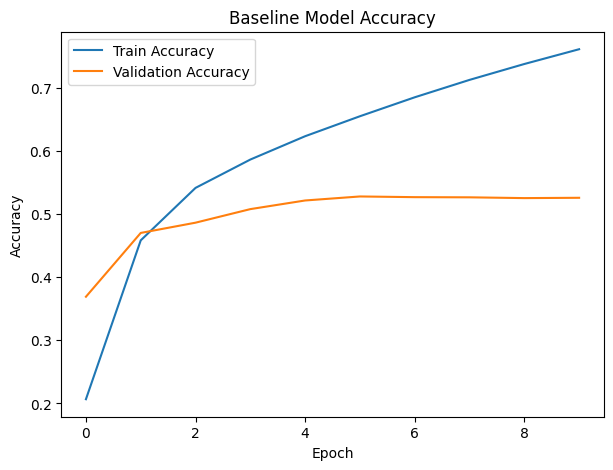

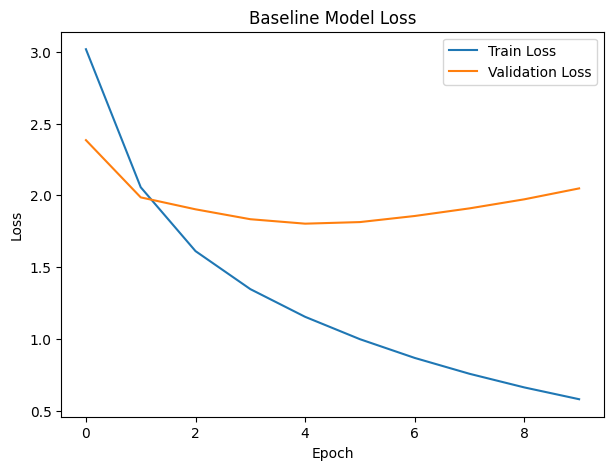

In [44]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(7,5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline Model Accuracy")
plt.legend()
plt.show()

# Loss plot
plt.figure(figsize=(7,5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline Model Loss")
plt.legend()
plt.show()

In [45]:

# validation perf at minim val loss

best_epoch = int(np.argmin(history.history["val_loss"]))
best_val_loss = history.history["val_loss"][best_epoch]
best_val_acc = history.history["val_accuracy"][best_epoch]

print("Best epoch (minimum val loss):", best_epoch + 1)
print("Validation loss at best epoch:", round(best_val_loss, 4))
print("Validation accuracy at best epoch:", round(best_val_acc, 4))

Best epoch (minimum val loss): 5
Validation loss at best epoch: 1.8031
Validation accuracy at best epoch: 0.5217


In [46]:
# evaluate on test

test_loss, test_acc = baseline_model.evaluate(test_ds, verbose=0)

print("Test loss:", round(test_loss, 4))
print("Test accuracy:", round(test_acc, 4))

Test loss: 1.7853
Test accuracy: 0.5253


In [47]:
# evaluation rubric

from sklearn.metrics import f1_score, classification_report, confusion_matrix

y_prob = baseline_model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

macro_f1 = f1_score(y_test, y_pred, average="macro")
print("Test macro-F1:", round(macro_f1, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

Test macro-F1: 0.4555

Classification Report:
                precision    recall  f1-score   support

          ARTS       0.29      0.28      0.29       225
ARTS & CULTURE       0.21      0.34      0.26       200
  BLACK VOICES       0.40      0.44      0.42       679
      BUSINESS       0.51      0.32      0.39       889
       COLLEGE       0.35      0.46      0.39       171
        COMEDY       0.42      0.46      0.44       764
         CRIME       0.38      0.68      0.49       510
CULTURE & ARTS       0.28      0.49      0.36       154
       DIVORCE       0.69      0.73      0.71       514
     EDUCATION       0.30      0.50      0.38       150
 ENTERTAINMENT       0.76      0.46      0.57      2407
   ENVIRONMENT       0.29      0.55      0.38       198
         FIFTY       0.17      0.33      0.23       209
  FOOD & DRINK       0.69      0.58      0.63       934
     GOOD NEWS       0.11      0.55      0.18       209
         GREEN       0.35      0.43      0.39       392
H

### Graded Questions (5 pts each)

1. **Model Architecture:**
   Describe your baseline model and justify why this structure suits your dataset.

2.1. **Your answer here:**



2. **Training Behavior:**
   Summarize the model’s training and validation curves. What trends did you observe?

2.2. **Your answer here:**



  3. **Baseline Metrics:**
   Report validation and test metrics. What does this performance tell you about dataset difficulty?

2.3. **Your answer here:**



  4. **Reflection:**
   What are the main limitations of your baseline? Which specific improvements (depth, regularization, pretraining) would you try next?
  

2.4. **Your answer here:**



## Problem 3 – Custom (Original) Model (20 pts)

### Goal

Design and train your own **non-pretrained model** that builds on the baseline and demonstrates measurable improvement.
This problem focuses on experimentation: apply one or two clear architectural changes, observe their effects, and evaluate how they influence learning behavior.


### Steps to Follow

1. **Modify or extend your baseline architecture**

   * Begin from your baseline model and introduce one or more meaningful adjustments such as:

     * Adding **dropout** or **batch normalization** for regularization.
     * Increasing **depth** (extra convolutional or dense layers).
     * Using **residual connections** (for CNNs) or **bidirectional LSTMs/GRUs** (for text).
     * Trying alternative activations like `ReLU`, `LeakyReLU`, or `GELU`.
   * Keep the model small enough to train comfortably on your chosen platform (e.g., Colab)

2. **Observe what specific limitations you want to address**

   * Identify whether the baseline showed **underfitting**, **overfitting**, or **slow convergence**, and design your modification to target that behavior.
   * Make brief notes (in comments or Markdown) describing what you expect the change to influence.

3. **Train and evaluate under the same conditions**

   * Use the **same data splits**, **random seed**, and **metrics** as in Problem 2.
   * Apply **early stopping** on validation loss.
   * Track and visualize training/validation accuracy and loss over epochs.

4. **Compare outcomes to the baseline**

   * Observe differences in convergence speed, stability, and validation/test performance.
   * Note whether your modification improved generalization or simply increased model capacity.

In [48]:
#overfitting, acc/ val plateau

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

num_classes = len(class_names)

custom_model = keras.Sequential([
    layers.Input(shape=(MAX_LEN,)),
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=96),
    layers.Bidirectional(layers.LSTM(48, dropout=0.2, recurrent_dropout=0.2)),
    layers.Dropout(0.5),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])

custom_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 128, 96)        │     1,920,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 96)             │        55,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 41)             │         2,665 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,984,553 (7.57 MB)

 Trainable params: 1,984,553 (7.57 MB)

 Non-trainable params: 0 (0.00 B)

In [49]:
custom_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [50]:
import time

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

start_time = time.time()

history_custom = custom_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

end_time = time.time()
custom_runtime_sec = end_time - start_time

print("Epochs trained:", len(history_custom.history["loss"]))
print("Total runtime (seconds):", round(custom_runtime_sec, 2))

Epoch 1/20
2190/2190 ━━━━━━━━━━━━━━━━━━━━ 329s 148ms/step - accuracy: 0.1594 - loss: 3.0724 - val_accuracy: 0.3618 - val_loss: 2.3611 - learning_rate: 0.0010
Epoch 2/20
2190/2190 ━━━━━━━━━━━━━━━━━━━━ 325s 148ms/step - accuracy: 0.3407 - loss: 2.2981 - val_accuracy: 0.4400 - val_loss: 2.0362 - learning_rate: 0.0010
Epoch 3/20
2190/2190 ━━━━━━━━━━━━━━━━━━━━ 327s 149ms/step - accuracy: 0.4200 - loss: 1.9503 - val_accuracy: 0.4718 - val_loss: 1.9256 - learning_rate: 0.0010
Epoch 4/20
2190/2190 ━━━━━━━━━━━━━━━━━━━━ 324s 148ms/step - accuracy: 0.4595 - loss: 1.7522 - val_accuracy: 0.4834 - val_loss: 1.9064 - learning_rate: 0.0010
Epoch 5/20
2190/2190 ━━━━━━━━━━━━━━━━━━━━ 324s 148ms/step - accuracy: 0.4875 - loss: 1.6081 - val_accuracy: 0.4954 - val_loss: 1.9019 - learning_rate: 0.0010
Epoch 6/20
2190/2190 ━━━━━━━━━━━━━━━━━━━━ 323s 148ms/step - accuracy: 0.5071 - loss: 1.5023 - val_accuracy: 0.4945 - val_loss: 1.9350 - learning_rate: 0.0010
Epoch 7/20
2190/2190 ━━━━━━━━━━━━━━━━━━━━ 319s 146ms

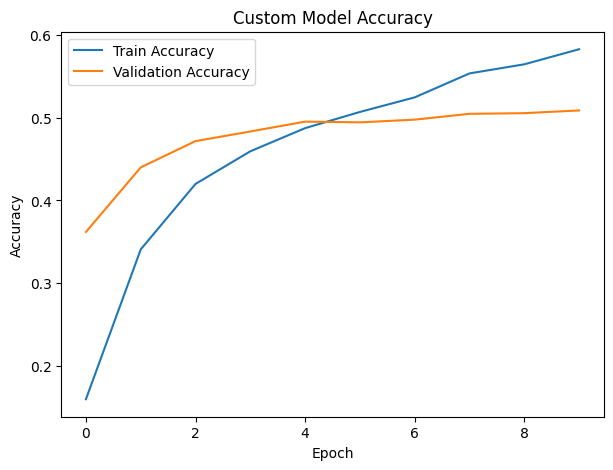

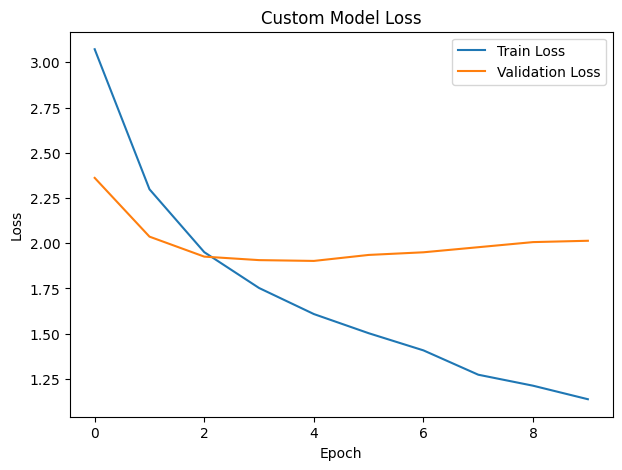

In [51]:
import matplotlib.pyplot as plt

# chart acc
plt.figure(figsize=(7,5))
plt.plot(history_custom.history["accuracy"], label="Train Accuracy")
plt.plot(history_custom.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Custom Model Accuracy")
plt.legend()
plt.show()
# chart loss
plt.figure(figsize=(7,5))
plt.plot(history_custom.history["loss"], label="Train Loss")
plt.plot(history_custom.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Custom Model Loss")
plt.legend()
plt.show()

In [52]:
import numpy as np

# best epoch
best_epoch_custom = int(np.argmin(history_custom.history["val_loss"]))
best_val_loss_custom = history_custom.history["val_loss"][best_epoch_custom]
best_val_acc_custom = history_custom.history["val_accuracy"][best_epoch_custom]

print("Best epoch (minimum val loss):", best_epoch_custom + 1)
print("Validation loss at best epoch:", round(best_val_loss_custom, 4))
print("Validation accuracy at best epoch:", round(best_val_acc_custom, 4))

Best epoch (minimum val loss): 5
Validation loss at best epoch: 1.9019
Validation accuracy at best epoch: 0.4954


In [53]:
from sklearn.metrics import f1_score, classification_report, confusion_matrix

test_loss_custom, test_acc_custom = custom_model.evaluate(test_ds, verbose=0)

y_prob_custom = custom_model.predict(test_ds, verbose=0)
y_pred_custom = np.argmax(y_prob_custom, axis=1)

macro_f1_custom = f1_score(y_test, y_pred_custom, average="macro")

print("Custom model test loss:", round(test_loss_custom, 4))
print("Custom model test accuracy:", round(test_acc_custom, 4))
print("Custom model test macro-F1:", round(macro_f1_custom, 4))

Custom model test loss: 1.8895
Custom model test accuracy: 0.496
Custom model test macro-F1: 0.4249


In [45]:
print("Baseline best val accuracy:", round(best_val_acc, 4))
print("Custom best val accuracy:  ", round(best_val_acc_custom, 4))
print()

print("Baseline test accuracy:", round(test_acc, 4))
print("Custom test accuracy:  ", round(test_acc_custom, 4))
print()

print("Baseline macro-F1:", round(macro_f1, 4))
print("Custom macro-F1:  ", round(macro_f1_custom, 4))
print()

print("Baseline runtime (sec):", round(runtime_sec, 2))
print("Custom runtime (sec):  ", round(custom_runtime_sec, 2))

Baseline best val accuracy: 0.5279
Custom best val accuracy:   0.4835

Baseline test accuracy: 0.5338
Custom test accuracy:   0.4878

Baseline macro-F1: 0.4597
Custom macro-F1:   0.4218

Baseline runtime (sec): 284.16
Custom runtime (sec):   1546.13


### Graded Questions (5 pts each)

1. **Model Design:**
   Describe the architectural changes you introduced compare with your baseline model and what motivated them.

3.1. **Your answer here:**



2. **Training Results:**
   Present key validation and test metrics. Did your modifications improve performance?

3.2. **Your answer here:**



3. **Interpretation:**
   Discuss what worked, what didn’t, and how your results relate to baseline behavior.

3.3. **Your answer here:**



4. **Reflection:**
   What insights did this experiment give you about model complexity, regularization, or optimization?

3.4. **Your answer here:**



## Problem 4 – Pretrained Model (Transfer Learning) (20 pts)

### Goal

Apply **transfer learning** to see how pretrained knowledge improves accuracy, convergence speed, and generalization.
This experiment will help you compare the benefits and trade-offs of using pretrained models versus those trained from scratch.


### Steps to Follow

1. **Select a pretrained architecture**

   * **Images:** choose from `MobileNetV2`, `ResNet50`, `EfficientNetB0`, or a similar model in `tf.keras.applications`.
   * **Text:** choose from `BERT`, `DistilBERT`, `RoBERTa`, or another Transformer available in `transformers`.

2. **Adapt the model for your dataset**

   * Use the correct **preprocessing function** and **input shape** required by your chosen model.
   * Replace the top layer with your own **classification head** (e.g., `Dense(num_classes, activation='softmax')`).

3. **Apply transfer learning**

   * Choose an appropriate **training strategy** for your pretrained model. Options include:

     * **Freezing** the pretrained base and training only a new classification head.
     * **Partially fine-tuning** selected upper layers of the base model.
     * **Full fine-tuning** (all layers trainable) with a reduced learning rate.
   * Adjust your learning rate schedule to match your strategy (e.g., smaller LR for fine-tuning).
   * Observe how your chosen approach affects **validation loss**, **training time**, and **model stability**.

4. **Train and evaluate under consistent conditions**

   * Use the same **splits**, **metrics**, and **evaluation protocol** as in earlier problems.
   * Record training duration, validation/test performance, and any resource constraints (GPU memory, runtime).

5. **Compare and analyze**

   * Observe how transfer learning changes both **performance** and **efficiency** relative to your baseline and custom models.
   * Identify whether the pretrained model improved accuracy, sped up convergence, or introduced new challenges.


In [31]:
import tensorflow as tf
import tf_keras as keras
from tf_keras import layers
from transformers import AutoTokenizer, TFAutoModel

keras.backend.clear_session()

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
bert_base = TFAutoModel.from_pretrained("distilbert-base-uncased")
bert_base.trainable = False

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_transform.weight', 'vocab_layer_norm.weight', 'vocab_projector.bias', 'vocab_layer_norm.bias', 'vocab_transform.bias']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFDistilBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDistilBertModel for predictions without further training.


In [32]:
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
bert_base = TFAutoModel.from_pretrained("distilbert-base-uncased")

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_transform.weight', 'vocab_layer_norm.weight', 'vocab_projector.bias', 'vocab_layer_norm.bias', 'vocab_transform.bias']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFDistilBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDistilBertModel for predictions without further training.


In [33]:
MAX_LEN = 128  # BERT

def tokenize_texts(texts):
    return tokenizer(
        list(texts),
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="tf"
    )

train_enc = tokenize_texts(X_train)
val_enc   = tokenize_texts(X_val)
test_enc  = tokenize_texts(X_test)

In [34]:
train_ds_bert = tf.data.Dataset.from_tensor_slices((
    dict(train_enc),
    y_train
)).batch(16).prefetch(tf.data.AUTOTUNE)

val_ds_bert = tf.data.Dataset.from_tensor_slices((
    dict(val_enc),
    y_val
)).batch(16).prefetch(tf.data.AUTOTUNE)

test_ds_bert = tf.data.Dataset.from_tensor_slices((
    dict(test_enc),
    y_test
)).batch(16).prefetch(tf.data.AUTOTUNE)

In [35]:
bert_base.trainable = False  # freeze for transfer learning

In [36]:
input_ids = keras.Input(shape=(MAX_LEN,), dtype=tf.int32, name="input_ids")
attention_mask = keras.Input(shape=(MAX_LEN,), dtype=tf.int32, name="attention_mask")

bert_outputs = bert_base(
    input_ids=input_ids,
    attention_mask=attention_mask
)

cls_token = layers.Lambda(lambda x: x[:, 0, :])(bert_outputs.last_hidden_state)
x = layers.Dense(128, activation="relu")(cls_token)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(len(class_names), activation="softmax")(x)

bert_model = keras.Model(
    inputs=[input_ids, attention_mask],
    outputs=outputs
)

bert_model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_ids (InputLayer)      [(None, 128)]                0         []                            
                                                                                                  
 attention_mask (InputLayer  [(None, 128)]                0         []                            
 )                                                                                                
                                                                                                  
 tf_distil_bert_model_1 (TF  TFBaseModelOutput(last_hid   6636288   ['input_ids[0][0]',           
 DistilBertModel)            den_state=(None, 128, 768)   0          'attention_mask[0][0]']      
                             , hidden_states=None, atte                                       

In [37]:
bert_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=2e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [38]:
import time

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

start_time = time.time()

history_bert = bert_model.fit(
    train_ds_bert,
    validation_data=val_ds_bert,
    epochs=5,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

end_time = time.time()
bert_runtime_sec = end_time - start_time

print("Runtime (sec):", round(bert_runtime_sec, 2))

Epoch 1/5
8758/8758 [==============================] - 111s 12ms/step - loss: 3.3847 - accuracy: 0.1604 - val_loss: 2.8026 - val_accuracy: 0.3693
Epoch 2/5
8758/8758 [==============================] - 105s 12ms/step - loss: 2.7914 - accuracy: 0.3001 - val_loss: 2.3806 - val_accuracy: 0.4253
Epoch 3/5
8758/8758 [==============================] - 105s 12ms/step - loss: 2.4935 - accuracy: 0.3470 - val_loss: 2.1617 - val_accuracy: 0.4517
Epoch 4/5
8758/8758 [==============================] - 105s 12ms/step - loss: 2.3222 - accuracy: 0.3736 - val_loss: 2.0491 - val_accuracy: 0.4639
Epoch 5/5
8758/8758 [==============================] - 105s 12ms/step - loss: 2.2119 - accuracy: 0.3915 - val_loss: 1.9768 - val_accuracy: 0.4719
Runtime (sec): 530.72


In [39]:
from sklearn.metrics import f1_score

test_loss_bert, test_acc_bert = bert_model.evaluate(test_ds_bert, verbose=0)

y_prob_bert = bert_model.predict(test_ds_bert, verbose=0)
y_pred_bert = y_prob_bert.argmax(axis=1)

macro_f1_bert = f1_score(y_test, y_pred_bert, average="macro")

print("BERT test accuracy:", round(test_acc_bert, 4))
print("BERT macro-F1:", round(macro_f1_bert, 4))

BERT test accuracy: 0.471
BERT macro-F1: 0.3882


In [54]:
print("Baseline acc:", round(test_acc, 4))
print("Custom acc:", round(test_acc_custom, 4))
print("BERT acc:", round(test_acc_bert, 4))

print()

print("Baseline F1:", round(macro_f1, 4))
print("Custom F1:", round(macro_f1_custom, 4))
print("BERT F1:", round(macro_f1_bert, 4))

print()

print("Baseline runtime:", round(runtime_sec, 2))
print("Custom runtime:", round(custom_runtime_sec, 2))
print("BERT runtime:", round(bert_runtime_sec, 2))

Baseline acc: 0.5253
Custom acc: 0.496
BERT acc: 0.471

Baseline F1: 0.4555
Custom F1: 0.4249
BERT F1: 0.3882

Baseline runtime: 39.15
Custom runtime: 3220.12
BERT runtime: 530.72


### Graded Questions (5 pts each)

1. **Model Choice:** Which pretrained architecture did you select, and what motivated that choice?

4.1. **Your answer here:**



2. **Fine-Tuning Plan:** Describe your fine-tuning strategy and why you chose it.

4.2. **Your answer here:**



3. **Performance:** Report key metrics and compare them with your baseline and custom models.

4.3. **Your answer here:**



4. **Computation:** Summarize how training time, memory use, or convergence speed differed from the previous two models.

4.4. **Your answer here:**



## Problem 5 – Comparative Evaluation and Discussion (20 pts)

### Goal

Compare your **baseline**, **custom**, and **pretrained** models to evaluate how design choices affected performance, efficiency, and generalization.
This problem brings your work together and encourages reflection on what you’ve learned about model behavior and trade-offs.

**Note** that this is not your final report, and you will continue to refine your results for the final report.

### Steps to Follow

1. **Compile key results**

   * Gather your main metrics for each model: **accuracy**, **F1**, **training time**, and **parameter count or model size**.
   * Ensure all numbers come from the same evaluation protocol and test set.

2. **Visualize the comparison**

   * Present results in a **single, well-organized chart or table**.
   * Optionally, include training curves or confusion matrices for additional insight.

3. **Analyze comparative performance**

   * Observe which model performed best by your chosen metric(s).
   * Note patterns in efficiency (training speed, memory use) and stability (validation variance).

4. **Inspect model behavior**

   * Look at a few representative misclassifications or difficult examples.
   * Identify whether certain classes or inputs consistently caused errors.

5. **Plan forward improvements**

   * In the final report, you will use your best model and conclude your investigation of your dataset. Based on your observations, decide on a model and next steps for refining your approach in the final project (e.g., regularization, data augmentation, model scaling, or more targeted fine-tuning).

### Graded Questions (4 pts each)

1. **Summary Table and Performance Analysis:** Present a clear quantitative comparison of all three models. Which model achieved the best overall results, and what factors contributed to its success?

5.1. **Your answer here:**



2. **Trade-Offs:** Discuss how complexity, accuracy, and efficiency balanced across your models.

5.2. **Your answer here:**



3. **Error Patterns:** Describe the types of examples or classes that remained challenging for all models.

5.3. **Your answer here:**



4. **Next Steps:** Based on these findings, decide on a model to go forward with and outline your plan for improving that model.


5.4 **Your answer here:**



### Final Question: Describe what use you made of generative AI tools in preparing this Milestone.

**AI Question: Your answer here:**